In [1]:
# import requests
import pandas as pd
import numpy as np
from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
# from statsmodels.tsa.stattools import adfuller  
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          

import itertools

import time
# import yaml
pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

## 1. Data Preparation

In [2]:
df_merged_detrended = pd.read_csv("dataset_FINAL_all_variables.csv")


In [3]:
df_merged_detrended.columns

Index(['date', 'workforce', 'inactives', 'employment_rate',
       'youth_employment_rate', 'activity_rate', 'unemployment_rate',
       'industry_production_prices', 'companies_trust', 'gasoline_car_price',
       'diesel_price', 'GPL_price', 'diesel_heatining_price', 'workforce_diff',
       'inactives_diff', 'employment_rate_diff', 'activity_rate_diff',
       'unemployment_rate_diff', 'industry_production_prices_diff',
       'gasoline_car_price_diff', 'diesel_price_diff',
       'diesel_heatining_price_diff', 'year', 'month', 'PCA_labour_market_1',
       'PCA_labour_market_2', 'PCA_price_energy_1', 'PCA_price_energy_2',
       'lag_12m', 'lag_1m', 'lag_2m', 'lag_3m', 'rolling_mean_12m',
       'rolling_mean_3m', 'rolling_mean_6m', 'rolling_std_12m'],
      dtype='str')

In [4]:
# df_merged_detrended.info() 

In [5]:
df_merged_detrended = df_merged_detrended[[ 'date',
                                            'year', 
                                            'month',
                                            'employment_rate_diff', 
                                            'industry_production_prices_diff', 'companies_trust',
                                            'rolling_mean_3m', 
                                            'rolling_mean_6m',
                                            'rolling_mean_12m', 
                                            'rolling_std_12m', 
                                            'lag_1m', 
                                            'lag_2m', 
                                            'lag_3m', #'lag_12m', 
                                            'PCA_labour_market_1', 
                                            'PCA_labour_market_2',
                                            'PCA_price_energy_1', 
                                            'PCA_price_energy_2',
                                            'unemployment_rate', 
                                            'unemployment_rate_diff'
                                            ]]

In [6]:
X_columns = df_merged_detrended.drop(['unemployment_rate','unemployment_rate_diff'], axis = 1)
X_columns.head(4)

,date,year,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,lag_1m,lag_2m,lag_3m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2
0,2014-02-01,2014,2,1.12,0.00,87.30,0.25,0.50,0.07,0.80,1.72,-0.95,0.26,1.01,0.01,0.06,0.13
1,2014-03-01,2014,3,0.17,-0.20,89.20,0.32,0.15,0.04,0.83,-0.02,1.72,-0.95,1.32,0.01,0.04,0.10
2,2014-04-01,2014,4,-1.24,-0.20,88.30,-0.35,-0.00,0.03,0.83,-0.73,-0.02,1.72,-2.75,0.00,0.03,0.08
3,2014-05-01,2014,5,2.21,-0.10,87.60,-0.38,-0.07,0.04,0.83,-0.30,-0.73,-0.02,1.92,0.01,0.05,0.07


In [7]:
X_columns['date'] = pd.to_datetime(X_columns['date'])
X_columns = X_columns.set_index('date')
df_merged_detrended['date'] = pd.to_datetime(df_merged_detrended['date'])
df_merged_detrended = df_merged_detrended.set_index('date')



In [92]:
X_columns.iloc[5:-24]

,year,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,lag_1m,lag_2m,lag_3m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2
date,,,,,,,,,,,,,,,,
2014-07-01,2014,7,0.40,-0.30,91.70,-0.33,-0.34,0.07,0.92,-1.50,-0.12,-0.30,0.64,-0.04,0.05,0.07
2014-08-01,2014,8,-0.42,0.00,88.40,-0.60,-0.49,0.00,0.97,0.63,-1.50,-0.12,-3.35,-0.02,0.02,0.08
2014-09-01,2014,9,-0.58,0.00,86.10,0.46,-0.09,0.03,1.02,-0.94,0.63,-1.50,4.31,0.00,0.02,0.08
2014-10-01,2014,10,0.59,-0.30,85.80,0.56,0.11,0.06,1.03,1.70,-0.94,0.63,2.66,-0.01,-0.01,0.08
2014-11-01,2014,11,-0.54,-0.20,85.50,1.16,0.28,0.10,1.06,0.91,1.70,-0.94,-0.42,-0.01,-0.04,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-01,2023,9,0.54,0.80,94.90,0.17,-0.12,-0.03,0.43,-0.59,0.51,-0.48,2.94,-0.00,0.12,-0.02
2023-10-01,2023,10,0.02,1.90,94.80,0.20,0.01,0.00,0.46,0.58,-0.59,0.51,2.07,0.00,-0.05,0.07
2023-11-01,2023,11,-0.30,-1.40,93.90,0.21,0.01,-0.02,0.48,0.60,0.58,-0.59,-2.39,0.07,-0.11,0.10


In [94]:
exog_train = X_columns.iloc[5:-24]
exog_val = X_columns.iloc[23:-12]
exog_test = X_columns.iloc[-12:]

y_train = df_merged_detrended.iloc[5:-24]['unemployment_rate_diff']
y_val = df_merged_detrended.iloc[23:-12]['unemployment_rate_diff']
y_test = df_merged_detrended.iloc[-12:]['unemployment_rate_diff']

In [18]:
# start = time.time()
# # Define the ranges for p, d, q parameters
# p = d = q = range(0, 3)

# # Create a list of all possible combinations of p, d, q values
# pdq = list(itertools.product(p, d, q))

# # Define the seasonal parameter combinations (P, D, Q, s)
# seasonal_pdq = [(x[0], x[1], x[2], 12) for x in pdq] 

# print(f'Minuti: {(time.time() - start)/60}')

In [10]:
# # Lists to store parameters and AIC values
# list_param = []
# list_param_seasonal = []
# list_results_aic = []

# # # Variables to track the best model
# best_aic = float("inf")  # Start with an infinitely large AIC value
# best_param = None
# best_param_seasonal = None

In [11]:
# # Loop over each combination of pdq and seasonal_pdq
# for param in pdq:
#     for param_seasonal in seasonal_pdq:
#         try:
#             # Fit the SARIMA model with the specified parameters
#             model = SARIMAX(y_train,
#                             exog=exog_train, 
#                             order=param,
#                             seasonal_order=param_seasonal,
#                             enforce_stationarity=False,
#                             enforce_invertibility=False)
#             results = model.fit()

#             # Save the parameter combination and its AIC
#             list_param.append(param)
#             list_param_seasonal.append(param_seasonal)
#             list_results_aic.append(results.aic)
            
#             # Print the current combination and its AIC
#             print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
            
#             # Update the best model if the current one has a lower AIC
#             if results.aic < best_aic:
#                 best_aic = results.aic
#                 best_param = param
#                 best_param_seasonal = param_seasonal
#         except:
#             # If the model fails to fit, skip this combination
#             continue

In [12]:
# # Print the best model parameters
# print("\nBest Model:")
# print('ARIMA{}x{}12 - AIC:{}'.format(best_param, best_param_seasonal, best_aic))

## 2. Model: SARIMAX

In [95]:
# best_param = (1, 1, 0)
# best_param_seasonal = (0, 1, 0, 12)

best_param = (0, 0, 0)
best_param_seasonal = (0, 0, 0, 12)

In [96]:
model = SARIMAX(y_train,
                exog=exog_train, 
                order=best_param,
                seasonal_order=best_param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


h = 12  # forecast horizon

# Training
# exog_train_pred = exog_train.iloc[-h:]  # 121 months
 

forecast_res = results.get_forecast(
    steps=h,
    exog=exog_train             # required if you used exog
)

forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05)  # 95% CI

# y_pred_train = results.predict(start=exog_train.index[-12], end=exog_train.index[-1], exog=exog_train[:-12] ), dynamic=True)

ValueError: Provided exogenous values are not of the appropriate shape. Required (12, 16), got (115, 16).

### Validation

In [93]:
val_forecast = results.get_forecast(
    steps=h,
    exog=exog_val
).predicted_mean

NameError: name 'exog_val' is not defined

### Testing

In [ ]:
h = 12  # forecast horizon

forecast_mean_test = results.get_forecast(
                                        steps=h,
                                        exog=exog_test              # required if you used exog
                                        ).predicted_mean

# y_pred = results.predict(start=exog_test.index[0], end=exog_test.index[-1], exog=exog_test, dynamic=True)


# conf_int = y_pred.conf_int(alpha=0.05)  # 95% CI

In [55]:
# forecast_mean_test
y_pred_train.iloc[-h:]

2024-02-01    0.45
2024-03-01   -0.70
2024-04-01   -0.54
2024-05-01   -0.36
2024-06-01    0.25
2024-07-01   -0.80
2024-08-01   -0.64
2024-09-01    0.29
2024-10-01    0.12
2024-11-01    0.08
2024-12-01    0.86
2025-01-01    0.43
Freq: MS, Name: predicted_mean, dtype: float64

In [54]:
y_train.iloc[-h:]

date
2024-02-01    0.45
2024-03-01   -0.70
2024-04-01   -0.54
2024-05-01   -0.36
2024-06-01    0.25
2024-07-01   -0.80
2024-08-01   -0.64
2024-09-01    0.29
2024-10-01    0.12
2024-11-01    0.08
2024-12-01    0.86
2025-01-01    0.43
Name: unemployment_rate_diff, dtype: float64

In [33]:
y_original = df_merged_detrended['unemployment_rate_diff'].iloc[-13] 

In [34]:
# Reversing the difference:
anchor =  df_merged_detrended['unemployment_rate'].iloc[-13] 
final_forecast = y_pred.cumsum() + anchor

In [35]:
final_forecast

2025-02-01   6.68
2025-03-01   6.85
2025-04-01   6.26
2025-05-01   7.08
2025-06-01   6.78
2025-07-01   5.93
2025-08-01   5.32
2025-09-01   6.04
2025-10-01   5.64
2025-11-01   5.52
2025-12-01   5.83
2026-01-01   5.21
Freq: MS, Name: predicted_mean, dtype: float64

In [41]:
y_train.iloc[-h:]

date
2024-02-01    0.45
2024-03-01   -0.70
2024-04-01   -0.54
2024-05-01   -0.36
2024-06-01    0.25
2024-07-01   -0.80
2024-08-01   -0.64
2024-09-01    0.29
2024-10-01    0.12
2024-11-01    0.08
2024-12-01    0.86
2025-01-01    0.43
Name: unemployment_rate_diff, dtype: float64

In [44]:
y_pred_train

2014-07-01    0.63
2014-08-01   -0.94
2014-09-01    1.70
2014-10-01    0.91
2014-11-01    0.86
              ... 
2024-09-01    0.29
2024-10-01    0.12
2024-11-01    0.08
2024-12-01    0.86
2025-01-01    0.43
Freq: MS, Name: predicted_mean, Length: 127, dtype: float64

In [45]:
print("------------------ NO PCA VARIABLES -------------------------")
print(f"RMSE train: {root_mean_squared_error(y_train.iloc[-h:], y_pred_train.iloc[-h:])}"), 
print(f"RMSE test : {root_mean_squared_error(y_test, y_pred)}")
                                        

------------------ NO PCA VARIABLES -------------------------
RMSE train: 5.508782582450975e-15
RMSE test : 5.769568233718604e-15


In [51]:
y_test

date
2025-02-01   -0.54
2025-03-01    0.17
2025-04-01   -0.59
2025-05-01    0.82
2025-06-01   -0.30
2025-07-01   -0.85
2025-08-01   -0.61
2025-09-01    0.72
2025-10-01   -0.40
2025-11-01   -0.12
2025-12-01    0.31
2026-01-01   -0.62
Name: unemployment_rate_diff, dtype: float64

In [50]:
y_pred.iloc[-h:]

2025-02-01   -0.54
2025-03-01    0.17
2025-04-01   -0.59
2025-05-01    0.82
2025-06-01   -0.30
2025-07-01   -0.85
2025-08-01   -0.61
2025-09-01    0.72
2025-10-01   -0.40
2025-11-01   -0.12
2025-12-01    0.31
2026-01-01   -0.62
Freq: MS, Name: predicted_mean, dtype: float64

### Plotting results

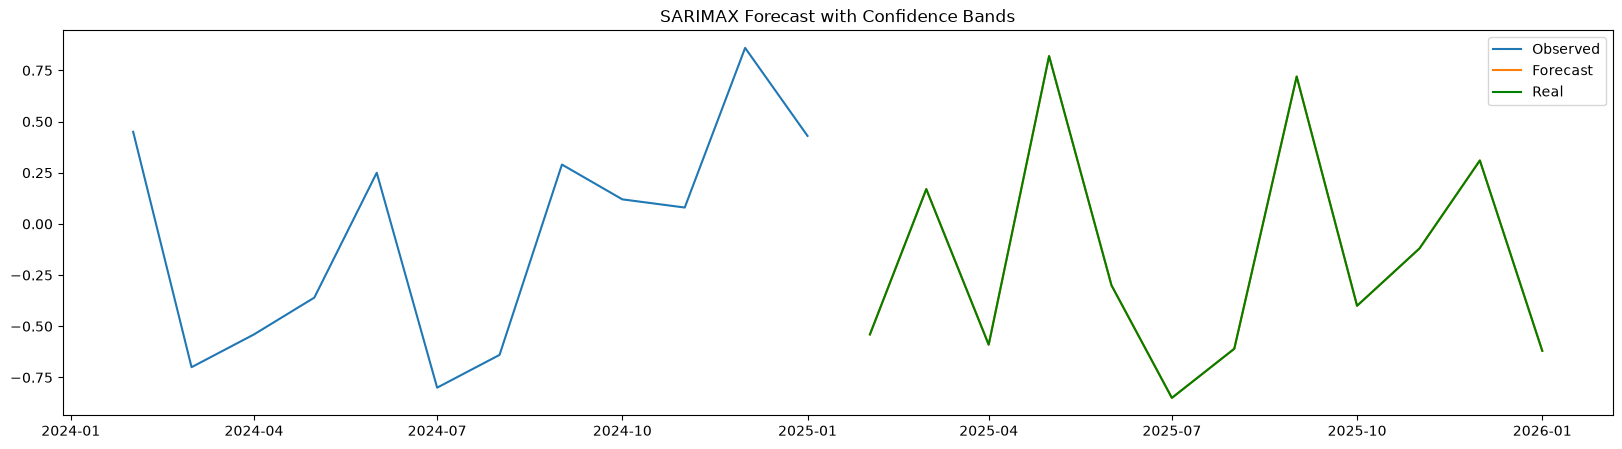

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(y_train.iloc[-h:].index, y_train.iloc[-h:], label='Observed')
plt.plot(y_pred.iloc[-h:].index, y_pred.iloc[-h:], label='Forecast', color='C1')
plt.plot(y_test.index, y_test, label='Real', color = 'green')

# plt.fill_between(
#     forecast_mean.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     color='C1',
#     alpha=0.3,
#     label='95% CI'
# )

plt.legend()
plt.title("SARIMAX Forecast with Confidence Bands")
plt.show()


In [31]:
anchor =  df_merged_detrended['unemployment_rate'].iloc[-13] 
final_forecast = forecast_mean_test.cumsum() + anchor

In [32]:
df_merged_detrended

,year,month,employment_rate_diff,industry_production_prices_diff,companies_trust,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,lag_1m,lag_2m,lag_3m,PCA_labour_market_1,PCA_labour_market_2,PCA_price_energy_1,PCA_price_energy_2,unemployment_rate,unemployment_rate_diff
date,,,,,,,,,,,,,,,,,,
2014-02-01,2014,2,1.12,0.00,87.30,0.25,0.50,0.07,0.80,1.72,-0.95,0.26,1.01,0.01,0.06,0.13,14.13,-0.02
2014-03-01,2014,3,0.17,-0.20,89.20,0.32,0.15,0.04,0.83,-0.02,1.72,-0.95,1.32,0.01,0.04,0.10,13.40,-0.73
2014-04-01,2014,4,-1.24,-0.20,88.30,-0.35,-0.00,0.03,0.83,-0.73,-0.02,1.72,-2.75,0.00,0.03,0.08,13.10,-0.30
2014-05-01,2014,5,2.21,-0.10,87.60,-0.38,-0.07,0.04,0.83,-0.30,-0.73,-0.02,1.92,0.01,0.05,0.07,12.98,-0.12
2014-06-01,2014,6,-0.40,0.20,89.30,-0.64,-0.16,-0.03,0.92,-0.12,-0.30,-0.73,-1.47,-0.01,0.04,0.07,11.48,-1.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-01,2025,9,0.78,0.30,93.80,-0.25,-0.13,0.03,0.60,-0.61,-0.85,-0.30,1.41,0.00,0.02,0.01,6.04,0.72
2025-10-01,2025,10,-0.83,-0.30,94.40,-0.10,-0.10,-0.02,0.61,0.72,-0.61,-0.85,-0.17,0.02,-0.01,0.02,5.64,-0.40
2025-11-01,2025,11,-0.28,1.20,96.10,0.07,-0.26,-0.03,0.61,-0.40,0.72,-0.61,-1.94,0.03,0.07,-0.02,5.52,-0.12


In [33]:
final_forecast

2025-02-01   6.68
2025-03-01   6.85
2025-04-01   6.26
2025-05-01   7.08
2025-06-01   6.78
2025-07-01   5.93
2025-08-01   5.32
2025-09-01   6.04
2025-10-01   5.64
2025-11-01   5.52
2025-12-01   5.83
2026-01-01   5.21
Freq: MS, Name: predicted_mean, dtype: float64

In [34]:
df_merged_detrended['unemployment_rate'].tail(12)

date
2025-02-01   6.68
2025-03-01   6.85
2025-04-01   6.26
2025-05-01   7.08
2025-06-01   6.78
2025-07-01   5.93
2025-08-01   5.32
2025-09-01   6.04
2025-10-01   5.64
2025-11-01   5.52
2025-12-01   5.83
2026-01-01   5.21
Name: unemployment_rate, dtype: float64

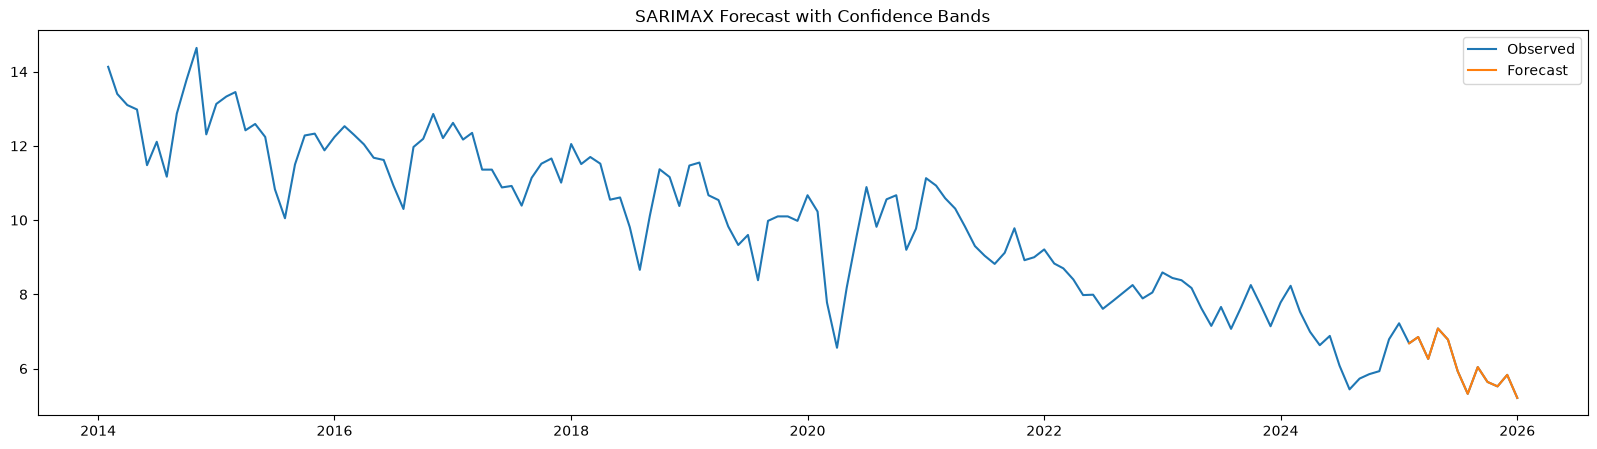

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(df_merged_detrended.index, df_merged_detrended['unemployment_rate'], label='Observed')
plt.plot(final_forecast.index, final_forecast, label='Forecast', color='C1')
# plt.plot(y_test.index, y_test, label='Real', color = 'green')

# plt.fill_between(
#     forecast_mean.index,
#     conf_int.iloc[:, 0],
#     conf_int.iloc[:, 1],
#     color='C1',
#     alpha=0.3,
#     label='95% CI'
# )

plt.legend()
plt.title("SARIMAX Forecast with Confidence Bands")
plt.show()


## 3. Saving the models and parameters

In [36]:
var_dict = {
"lags" : results.k_ar
,"variables": results.names
,"params" : results.params.to_dict()
# ,"sigma_u" : results.sigma_u.tolist()
#  ,"aic" : results.aic
#  ,"bic" : results.bic
}

AttributeError: 'SARIMAXResults' object has no attribute 'k_ar'

In [ ]:
from pathlib import Path
 
BASE_DIR = Path.cwd()   # current working directory
CONFIG_PATH = BASE_DIR / "configs" 

with open(CONFIG_PATH / "SARIMAX_baseline.yaml", "w") as f:
    yaml.safe_dump(var_dict)

In [ ]:
import pickle

BASE_DIR = Path.cwd()   # current working directory
PATH = BASE_DIR / "models" 

with open(PATH / "SARIMAX_model.pkl", "wb") as f:
    pickle.dump(results, f)